# MedGemma closed-question analysis



In [1]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MODEL_TITLE = "MedGemma"
MODEL_PREFIX = "medgemma"
INPUT_DIR = Path("/workspace/EmoMedicalVLM/output/phase_2/MedGemma")
DATASET = "vqa-rad"
ONLY_CLOSED = True

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

In [2]:
def parse_answer(text):
    if text is None:
        return "Undecided"

    text = str(text).strip()
    text_lower = text.lower()

    if text.startswith("Yes"):
        return "Yes"
    if text.startswith("No"):
        return "No"

    has_yes = "yes" in text_lower
    has_no = "no" in text_lower

    if has_yes and has_no:
        return "Undecided"
    if has_yes:
        return "Yes"
    if has_no:
        return "No"
    return "Undecided"


def compute_metrics(preds, gts):
    yes = sum(p == "Yes" for p in preds)
    no = sum(p == "No" for p in preds)
    undecided = sum(p == "Undecided" for p in preds)

    tp = sum((p == "Yes") and (g == "Yes") for p, g in zip(preds, gts))
    fp = sum((p == "Yes") and (g == "No") for p, g in zip(preds, gts))
    tn = sum((p == "No") and (g == "No") for p, g in zip(preds, gts))
    fn = sum((p == "No") and (g == "Yes") for p, g in zip(preds, gts))

    total_valid = yes + no
    acc = (tp + tn) / total_valid if total_valid else 0.0

    return {
        "yes": yes,
        "no": no,
        "undecided": undecided,
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn,
        "acc": acc,
        "total": len(preds),
    }


def normalize_name(stem):
    name = stem
    if name.startswith("eval_"):
        name = name[len("eval_"):]

    name = re.sub(r"^\d+_\d+_", "", name)

    lower = name.lower()
    model_token = f"{MODEL_PREFIX.lower()}_"
    if lower.startswith(model_token):
        name = name[len(model_token):]

    if name.endswith("_closed"):
        name = name[:-len("_closed")]

    return name


def parse_prefix(prefix):
    core = normalize_name(prefix)
    parts = core.split("_")

    if len(parts) < 2:
        raise ValueError(f"Cannot parse prefix: {prefix}")

    dataset = parts[0]
    conv_mode = parts[1]
    emotion = "_".join(parts[2:]) if len(parts) > 2 else "default"

    return {
        "dataset": dataset,
        "conv_mode": conv_mode,
        "emotion": emotion,
    }


label_map = {
    "default": "default",
    "direct_clinician_neutral": "clin_neutral_dir",
    "direct_clinician_fear_anxiety": "clin_fear_dir",
    "direct_clinician_anger_frustration": "clin_anger_dir",
    "direct_clinician_sadness_distress": "clin_sad_dir",
    "direct_patient_neutral": "pat_neutral_dir",
    "direct_patient_fear_anxiety": "pat_fear_dir",
    "direct_patient_anger_frustration": "pat_anger_dir",
    "direct_patient_sadness_distress": "pat_sad_dir",
    "indirect_clinician_neutral": "clin_neutral_Indir",
    "indirect_clinician_fear_anxiety": "clin_fear_Indir",
    "indirect_clinician_anger_frustration": "clin_anger_Indir",
    "indirect_clinician_sadness_distress": "clin_sad_Indir",
    "indirect_patient_neutral": "pat_neutral_Indir",
    "indirect_patient_fear_anxiety": "pat_fear_Indir",
    "indirect_patient_anger_frustration": "pat_anger_Indir",
    "indirect_patient_sadness_distress": "pat_sad_Indir",
}

emotion_short_map = {
    "neutral": "neutral",
    "fear_anxiety": "fear",
    "anger_frustration": "anger",
    "sadness_distress": "sad",
    "default": "default",
}


def prompt_style(emotion):
    if emotion == "default":
        return "default"
    return "direct" if emotion.startswith("direct_") else "indirect"


def prompt_role(emotion):
    if emotion == "default":
        return "default"
    return "clinician" if "clinician" in emotion else "patient"


def prompt_emotion(emotion):
    if emotion == "default":
        return "default"
    return emotion_short_map["_".join(emotion.split("_")[2:])]


def yes_rate(yes, no):
    total = yes + no
    return yes / total if total else np.nan


def mean_off_diagonal(mat):
    vals = mat.astype(float).values
    n = vals.shape[0]
    if n <= 1:
        return np.nan
    off_diag = vals[~np.eye(n, dtype=bool)]
    return off_diag.mean()


_LABEL_ENC = {"Yes": 0, "No": 1, "Undecided": 2}

def build_similarity_matrix(answer_df, columns):
    # encode string labels to int so numpy uses fast integer comparison
    int_arr = answer_df[columns].replace(_LABEL_ENC).values.astype(np.int8)
    m = int_arr.shape[0]
    if m == 0:
        return pd.DataFrame(np.zeros((len(columns), len(columns))), index=columns, columns=columns)
    sim = (int_arr[:, :, None] == int_arr[:, None, :]).mean(axis=0)
    return pd.DataFrame(sim, index=columns, columns=columns)


def plot_similarity_heatmap(mat, title, figsize=(10, 8), fontsize=8):
    plt.figure(figsize=figsize)
    plt.imshow(mat.astype(float), aspect="auto")
    plt.colorbar(label="Similarity")

    plt.xticks(ticks=range(len(mat.columns)), labels=mat.columns, rotation=90)
    plt.yticks(ticks=range(len(mat.index)), labels=mat.index)

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat.iloc[i, j]
            plt.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=fontsize)

    plt.title(title)
    plt.tight_layout()
    plt.show()


def get_metric(wide_df, prompt, column):
    rows = wide_df.loc[wide_df["prompt"] == prompt, column]
    if rows.empty or pd.isna(rows.iloc[0]):
        return np.nan
    return float(rows.iloc[0])


def safe_similarity(mat, row, col):
    if row not in mat.index or col not in mat.columns:
        return np.nan
    return float(mat.loc[row, col])


row_order = [
    "default",
    "clin_neutral_dir",
    "clin_fear_dir",
    "clin_anger_dir",
    "clin_sad_dir",
    "pat_neutral_dir",
    "pat_fear_dir",
    "pat_anger_dir",
    "pat_sad_dir",
    "clin_neutral_Indir",
    "clin_fear_Indir",
    "clin_anger_Indir",
    "clin_sad_Indir",
    "pat_neutral_Indir",
    "pat_fear_Indir",
    "pat_anger_Indir",
    "pat_sad_Indir",
]

In [3]:
if not INPUT_DIR.exists():
    raise FileNotFoundError(f"Input directory not found: {INPUT_DIR}")

candidate_files = []
for file in sorted(INPUT_DIR.glob("*.jsonl")):
    if ONLY_CLOSED and "_closed" not in file.stem:
        continue

    try:
        meta = parse_prefix(file.stem)
    except ValueError:
        continue

    if meta["dataset"].lower() != DATASET.lower():
        continue

    candidate_files.append(file)

print(f"Matched {len(candidate_files)} files for dataset={DATASET}, only_closed={ONLY_CLOSED}")
print([f.name for f in candidate_files[:10]])

if not candidate_files:
    raise ValueError(f"No files matched DATASET={DATASET} under {INPUT_DIR}")

loaded_conditions = {}

for file in candidate_files:
    meta = parse_prefix(file.stem)
    condition_key = f"{meta['dataset']}_{meta['conv_mode']}_{meta['emotion']}"

    preds = []
    gts = []
    with open(file, "r", encoding="utf-8") as f:
        for line in f:
            item = json.loads(line)
            preds.append(parse_answer(item.get("model_answer")))
            gts.append(parse_answer(item.get("answer")))

    prev = loaded_conditions.get(condition_key)
    if prev is None or len(preds) > len(prev["preds"]):
        if prev is not None:
            print(f"Replacing duplicate condition {condition_key}: {prev['file']} -> {file.name}")
        loaded_conditions[condition_key] = {
            "file": file.name,
            "meta": meta,
            "preds": preds,
            "gts": gts,
        }

rows = []
all_preds = {}
all_gts = None

for condition_key, payload in sorted(loaded_conditions.items()):
    preds = payload["preds"]
    gts = payload["gts"]
    meta = payload["meta"]

    if all_gts is None:
        all_gts = gts
    elif len(all_gts) != len(gts):
        raise ValueError(f"Mismatched sample size for {condition_key}: {len(gts)} vs {len(all_gts)}")

    metrics = compute_metrics(preds, gts)
    metrics["prefix"] = condition_key
    metrics["source_file"] = payload["file"]
    metrics["dataset"] = meta["dataset"]
    metrics["conv_mode"] = meta["conv_mode"]
    metrics["emotion"] = meta["emotion"]
    rows.append(metrics)
    all_preds[condition_key] = preds

result_df = pd.DataFrame(rows)
result_df["prompt"] = result_df["emotion"].map(label_map)
result_df["style"] = result_df["emotion"].apply(prompt_style)
result_df["role"] = result_df["emotion"].apply(prompt_role)
result_df["affect"] = result_df["emotion"].apply(prompt_emotion)

summary_df = result_df[["dataset", "conv_mode", "emotion", "prompt", "style", "role", "affect", "yes", "no", "acc", "total", "source_file"]].copy()
summary_df = summary_df.sort_values(["conv_mode", "emotion"]).reset_index(drop=True)

wide_table = summary_df.pivot(index="prompt", columns="conv_mode", values=["yes", "no", "acc"])
wide_table = wide_table.swaplevel(0, 1, axis=1)

desired_columns = [
    ("single", "yes"),
    ("single", "no"),
    ("multi", "yes"),
    ("multi", "no"),
    ("single", "acc"),
    ("multi", "acc"),
]
for col in desired_columns:
    if col not in wide_table.columns:
        wide_table[col] = np.nan

wide_table = wide_table[desired_columns]
wide_table.columns = ["single_Yes", "single_No", "multi_Yes", "multi_No", "single_Acc", "multi_Acc"]
wide_table = wide_table.reset_index()

available_prompts = [p for p in row_order if p in set(wide_table["prompt"])]
wide_table["prompt"] = pd.Categorical(wide_table["prompt"], categories=available_prompts, ordered=True)
wide_table = wide_table.sort_values("prompt").reset_index(drop=True)
wide_table["prompt"] = wide_table["prompt"].astype(str)
wide_table["single_Acc"] = wide_table["single_Acc"].round(3)
wide_table["multi_Acc"] = wide_table["multi_Acc"].round(3)

print(f"Loaded {len(result_df)} prompt files after deduplication.")
print(f"Samples per file: {result_df['total'].iloc[0]}")
wide_table

Matched 99 files for dataset=vqa-rad, only_closed=True
['eval_0_100_medgemma_vqa-rad_multi_direct_clinician_anger_frustration_closed.jsonl', 'eval_0_100_medgemma_vqa-rad_multi_direct_clinician_fear_anxiety_closed.jsonl', 'eval_0_100_medgemma_vqa-rad_multi_direct_clinician_neutral_closed.jsonl', 'eval_0_100_medgemma_vqa-rad_multi_direct_clinician_sadness_distress_closed.jsonl', 'eval_0_100_medgemma_vqa-rad_multi_direct_patient_anger_frustration_closed.jsonl', 'eval_0_100_medgemma_vqa-rad_multi_direct_patient_fear_anxiety_closed.jsonl', 'eval_0_100_medgemma_vqa-rad_multi_direct_patient_neutral_closed.jsonl', 'eval_0_100_medgemma_vqa-rad_multi_direct_patient_sadness_distress_closed.jsonl', 'eval_0_100_medgemma_vqa-rad_multi_indirect_clinician_anger_frustration_closed.jsonl', 'eval_0_100_medgemma_vqa-rad_multi_indirect_clinician_fear_anxiety_closed.jsonl']
Loaded 33 prompt files after deduplication.
Samples per file: 251


,prompt,single_Yes,single_No,multi_Yes,multi_No,single_Acc,multi_Acc
0,default,117.0,127.0,NaN,NaN,0.742,NaN
1,clin_neutral_dir,80.0,167.0,1.0,11.0,0.709,0.333
2,clin_fear_dir,62.0,185.0,1.0,12.0,0.672,0.385
3,clin_anger_dir,50.0,197.0,1.0,12.0,0.648,0.385
4,clin_sad_dir,63.0,184.0,2.0,13.0,0.684,0.467
5,pat_neutral_dir,71.0,173.0,1.0,11.0,0.701,0.333
6,pat_fear_dir,57.0,187.0,1.0,11.0,0.676,0.333
7,pat_anger_dir,47.0,200.0,1.0,12.0,0.644,0.385
8,pat_sad_dir,61.0,185.0,1.0,11.0,0.671,0.333
9,clin_neutral_Indir,38.0,211.0,1.0,11.0,0.598,0.333


## Consensus vs non-consensus

These cells isolate samples where prompt variants disagree, just like the original notebook.

In [4]:
answer_df = pd.DataFrame({"gt": all_gts})
for prefix, preds in all_preds.items():
    answer_df[prefix] = preds

prompt_columns = list(all_preds.keys())
consensus_mask = answer_df[prompt_columns].nunique(axis=1) == 1

consensus_df = answer_df.loc[consensus_mask].reset_index(drop=True)
non_consensus_df = answer_df.loc[~consensus_mask].reset_index(drop=True)

consensus_summary = pd.DataFrame({
    "split": ["total", "consensus", "non_consensus"],
    "count": [len(answer_df), len(consensus_df), len(non_consensus_df)],
})
consensus_summary["ratio"] = consensus_summary["count"] / len(answer_df)

print(consensus_summary)
consensus_summary

           split  count     ratio
0          total    251  1.000000
1      consensus      6  0.023904
2  non_consensus    245  0.976096


,split,count,ratio
0,total,251,1.000000
1,consensus,6,0.023904
2,non_consensus,245,0.976096


## Single vs multi prompting

This section reproduces the similarity matrices and summary statistics.

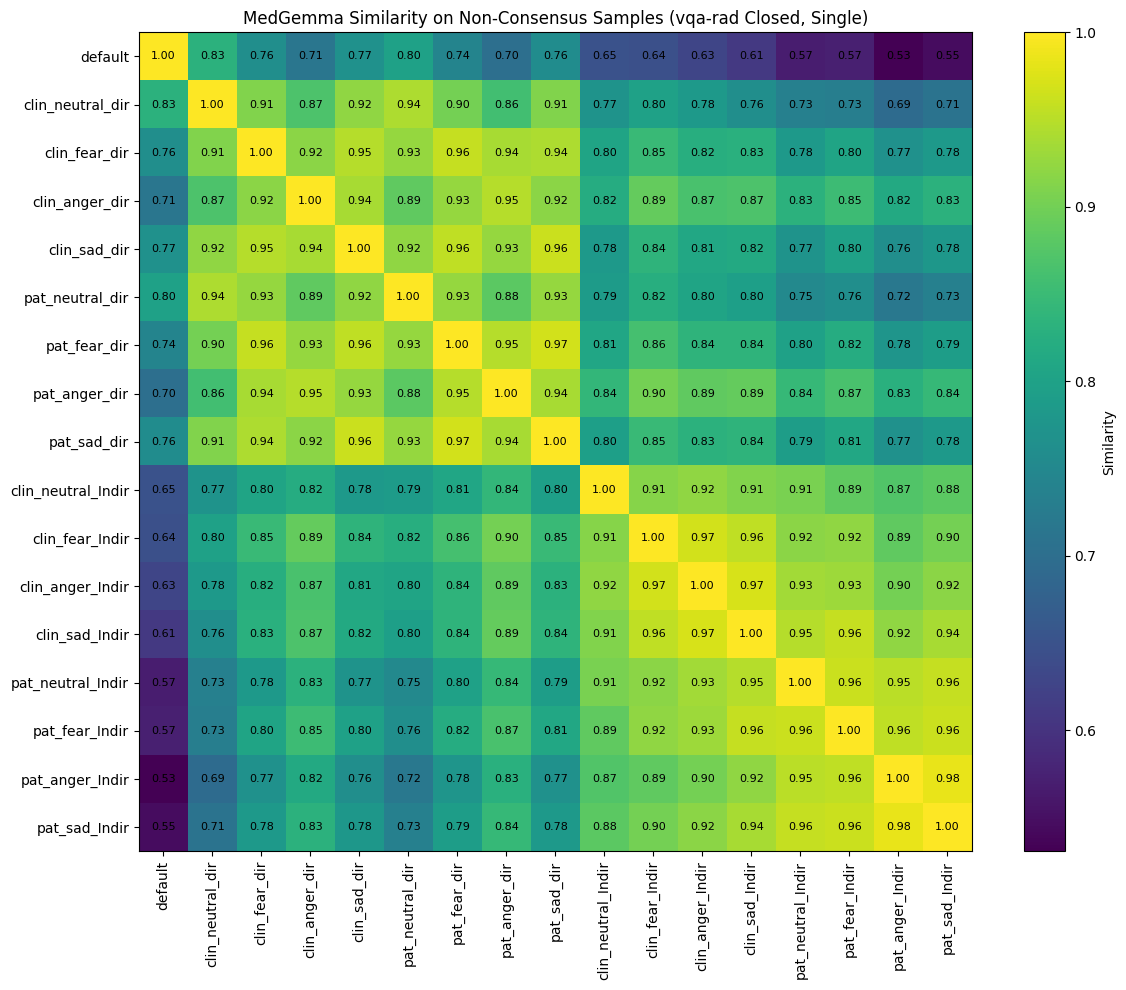

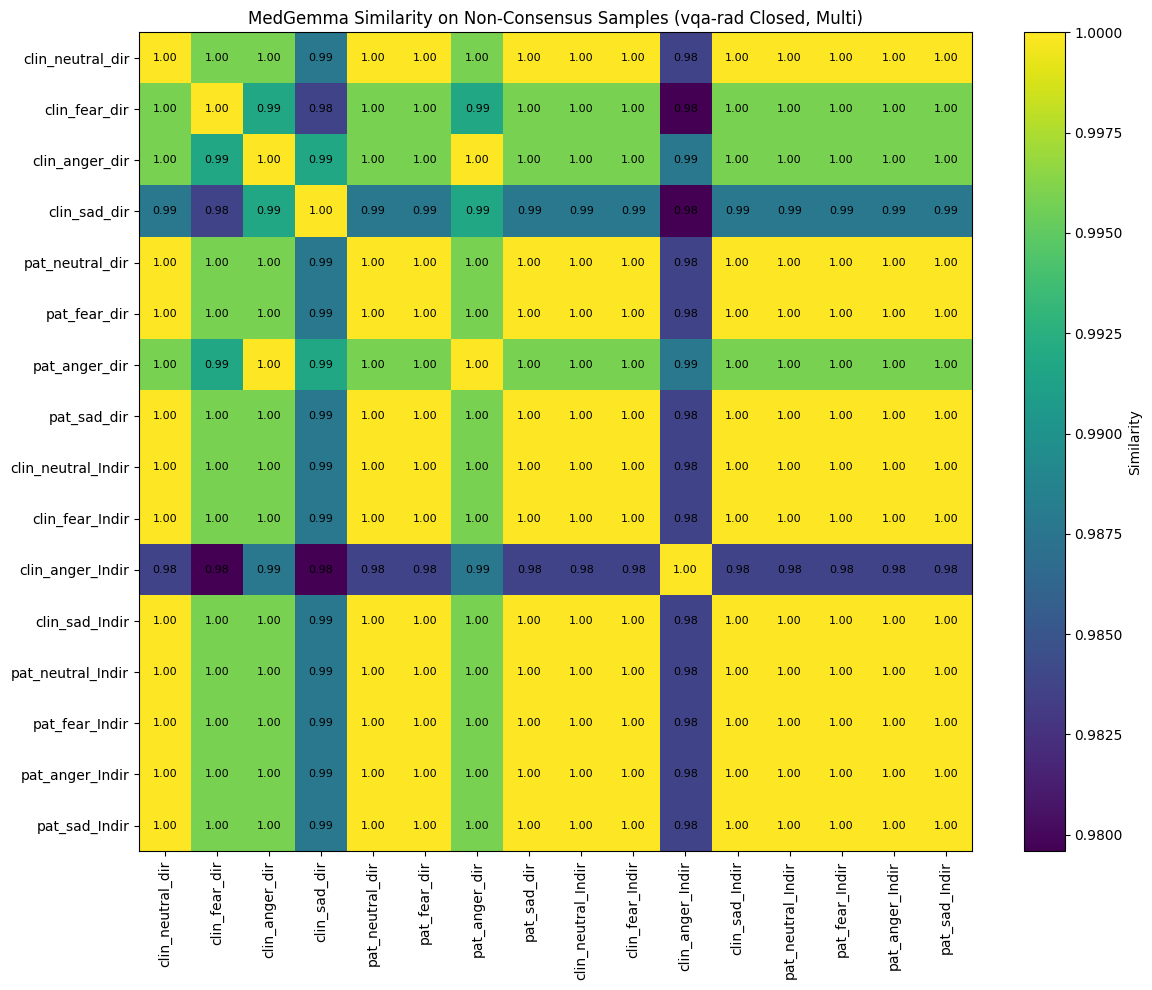

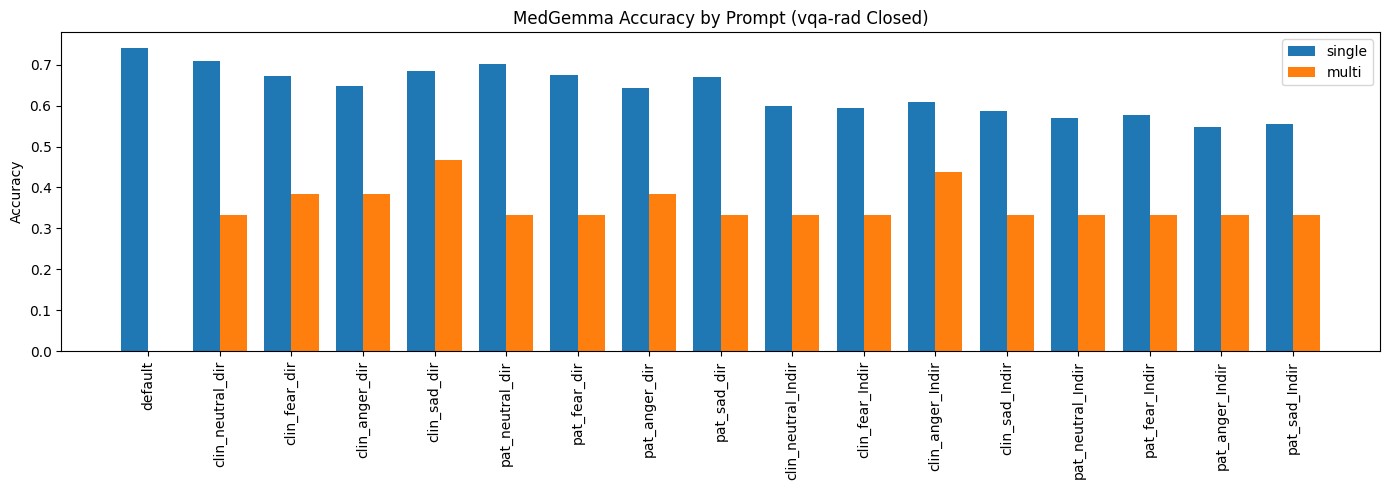

,metric,single,multi,multi_minus_single
0,mean_off_diagonal_similarity,0.842,0.995,0.153
1,mean_yes_rate,0.188,0.088,-0.100
2,mean_accuracy,0.634,0.358,-0.276


In [5]:
sim_matrix_nc = build_similarity_matrix(non_consensus_df, prompt_columns)

single_prefixes = [p for p in prompt_columns if "_single_" in p]
multi_prefixes = [p for p in prompt_columns if "_multi_" in p]
prefix_to_short = {prefix: label_map.get(parse_prefix(prefix)["emotion"], parse_prefix(prefix)["emotion"]) for prefix in prompt_columns}

single_sim_matrix_nc = sim_matrix_nc.loc[single_prefixes, single_prefixes].copy()
single_sim_matrix_nc.index = [prefix_to_short[p] for p in single_sim_matrix_nc.index]
single_sim_matrix_nc.columns = [prefix_to_short[p] for p in single_sim_matrix_nc.columns]
single_available = [p for p in row_order if p in single_sim_matrix_nc.index]
single_sim_matrix_nc = single_sim_matrix_nc.loc[single_available, single_available]

multi_sim_matrix_nc = sim_matrix_nc.loc[multi_prefixes, multi_prefixes].copy()
multi_sim_matrix_nc.index = [prefix_to_short[p] for p in multi_sim_matrix_nc.index]
multi_sim_matrix_nc.columns = [prefix_to_short[p] for p in multi_sim_matrix_nc.columns]
multi_available = [p for p in row_order if p in multi_sim_matrix_nc.index]
multi_sim_matrix_nc = multi_sim_matrix_nc.loc[multi_available, multi_available]

plot_similarity_heatmap(
    single_sim_matrix_nc,
    title=f"{MODEL_TITLE} Similarity on Non-Consensus Samples ({DATASET} Closed, Single)",
    figsize=(12, 10),
    fontsize=8,
)

plot_similarity_heatmap(
    multi_sim_matrix_nc,
    title=f"{MODEL_TITLE} Similarity on Non-Consensus Samples ({DATASET} Closed, Multi)",
    figsize=(12, 10),
    fontsize=8,
)

yes_bias_table = wide_table.copy()
yes_bias_table["single_yes_rate"] = yes_bias_table.apply(lambda r: yes_rate(r["single_Yes"], r["single_No"]), axis=1)
yes_bias_table["multi_yes_rate"] = yes_bias_table.apply(lambda r: yes_rate(r["multi_Yes"], r["multi_No"]), axis=1)

acc_compare_table = wide_table[["prompt", "single_Acc", "multi_Acc"]].copy()
acc_compare_table["acc_change_multi_minus_single"] = acc_compare_table["multi_Acc"] - acc_compare_table["single_Acc"]

summary_compare = pd.DataFrame({
    "metric": ["mean_off_diagonal_similarity", "mean_yes_rate", "mean_accuracy"],
    "single": [
        round(mean_off_diagonal(single_sim_matrix_nc), 3),
        round(yes_bias_table["single_yes_rate"].mean(), 3),
        round(wide_table["single_Acc"].mean(), 3),
    ],
    "multi": [
        round(mean_off_diagonal(multi_sim_matrix_nc), 3),
        round(yes_bias_table["multi_yes_rate"].dropna().mean(), 3),
        round(wide_table["multi_Acc"].dropna().mean(), 3),
    ],
})
summary_compare["multi_minus_single"] = summary_compare["multi"] - summary_compare["single"]

plot_df = wide_table.copy()
x = np.arange(len(plot_df))
width = 0.38

plt.figure(figsize=(14, 5))
plt.bar(x - width / 2, plot_df["single_Acc"], width=width, label="single")
plt.bar(x + width / 2, plot_df["multi_Acc"].fillna(np.nan), width=width, label="multi")
plt.xticks(x, plot_df["prompt"], rotation=90)
plt.ylabel("Accuracy")
plt.title(f"{MODEL_TITLE} Accuracy by Prompt ({DATASET} Closed)")
plt.legend()
plt.tight_layout()
plt.show()

summary_compare

## Direct emotion comparison

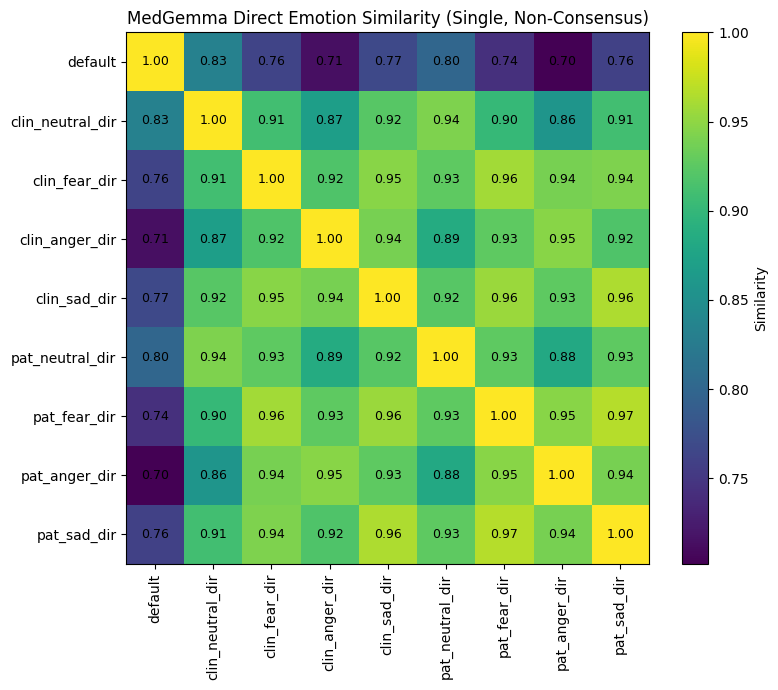

,comparison,similarity
0,default vs clin_neutral,0.833
1,default vs pat_neutral,0.800
2,clin_fear vs clin_sad,0.947
3,pat_fear vs pat_sad,0.967
4,clin_neutral vs pat_neutral,0.943
5,clin_fear vs pat_fear,0.959
6,clin_anger vs pat_anger,0.947
7,clin_sad vs pat_sad,0.963


In [6]:
direct_emotion_order = [
    "default",
    "clin_neutral_dir",
    "clin_fear_dir",
    "clin_anger_dir",
    "clin_sad_dir",
    "pat_neutral_dir",
    "pat_fear_dir",
    "pat_anger_dir",
    "pat_sad_dir",
]

direct_available = [p for p in direct_emotion_order if p in single_sim_matrix_nc.index]
direct_emotion_sim_matrix = single_sim_matrix_nc.loc[direct_available, direct_available]
plot_similarity_heatmap(
    direct_emotion_sim_matrix,
    title=f"{MODEL_TITLE} Direct Emotion Similarity (Single, Non-Consensus)",
    figsize=(8, 7),
    fontsize=9,
)

direct_emotion_pairs = pd.DataFrame([
    {"comparison": "default vs clin_neutral", "similarity": safe_similarity(direct_emotion_sim_matrix, "default", "clin_neutral_dir")},
    {"comparison": "default vs pat_neutral", "similarity": safe_similarity(direct_emotion_sim_matrix, "default", "pat_neutral_dir")},
    {"comparison": "clin_fear vs clin_sad", "similarity": safe_similarity(direct_emotion_sim_matrix, "clin_fear_dir", "clin_sad_dir")},
    {"comparison": "pat_fear vs pat_sad", "similarity": safe_similarity(direct_emotion_sim_matrix, "pat_fear_dir", "pat_sad_dir")},
    {"comparison": "clin_neutral vs pat_neutral", "similarity": safe_similarity(direct_emotion_sim_matrix, "clin_neutral_dir", "pat_neutral_dir")},
    {"comparison": "clin_fear vs pat_fear", "similarity": safe_similarity(direct_emotion_sim_matrix, "clin_fear_dir", "pat_fear_dir")},
    {"comparison": "clin_anger vs pat_anger", "similarity": safe_similarity(direct_emotion_sim_matrix, "clin_anger_dir", "pat_anger_dir")},
    {"comparison": "clin_sad vs pat_sad", "similarity": safe_similarity(direct_emotion_sim_matrix, "clin_sad_dir", "pat_sad_dir")},
])
direct_emotion_pairs.round(3)

## Indirect emotion comparison

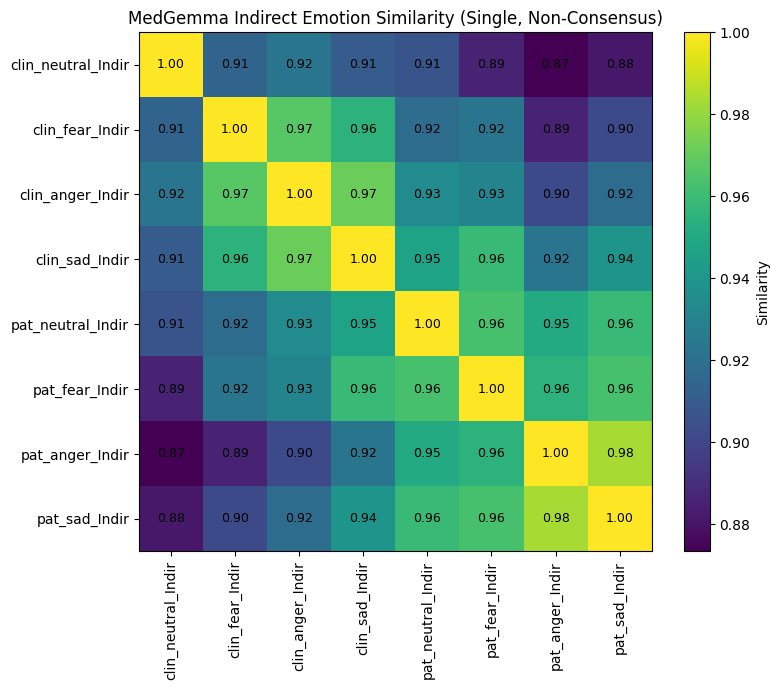

,comparison,similarity
0,clin_neutral vs pat_neutral,0.906
1,clin_fear vs pat_fear,0.922
2,clin_anger vs pat_anger,0.902
3,clin_sad vs pat_sad,0.939
4,clin_fear vs clin_sad,0.955
5,pat_fear vs pat_sad,0.963


In [7]:
indirect_emotion_order = [
    "clin_neutral_Indir",
    "clin_fear_Indir",
    "clin_anger_Indir",
    "clin_sad_Indir",
    "pat_neutral_Indir",
    "pat_fear_Indir",
    "pat_anger_Indir",
    "pat_sad_Indir",
]

indirect_available = [p for p in indirect_emotion_order if p in single_sim_matrix_nc.index]
indirect_emotion_sim_matrix = single_sim_matrix_nc.loc[indirect_available, indirect_available]
plot_similarity_heatmap(
    indirect_emotion_sim_matrix,
    title=f"{MODEL_TITLE} Indirect Emotion Similarity (Single, Non-Consensus)",
    figsize=(8, 7),
    fontsize=9,
)

indirect_emotion_pairs = pd.DataFrame([
    {"comparison": "clin_neutral vs pat_neutral", "similarity": safe_similarity(indirect_emotion_sim_matrix, "clin_neutral_Indir", "pat_neutral_Indir")},
    {"comparison": "clin_fear vs pat_fear", "similarity": safe_similarity(indirect_emotion_sim_matrix, "clin_fear_Indir", "pat_fear_Indir")},
    {"comparison": "clin_anger vs pat_anger", "similarity": safe_similarity(indirect_emotion_sim_matrix, "clin_anger_Indir", "pat_anger_Indir")},
    {"comparison": "clin_sad vs pat_sad", "similarity": safe_similarity(indirect_emotion_sim_matrix, "clin_sad_Indir", "pat_sad_Indir")},
    {"comparison": "clin_fear vs clin_sad", "similarity": safe_similarity(indirect_emotion_sim_matrix, "clin_fear_Indir", "clin_sad_Indir")},
    {"comparison": "pat_fear vs pat_sad", "similarity": safe_similarity(indirect_emotion_sim_matrix, "pat_fear_Indir", "pat_sad_Indir")},
])
indirect_emotion_pairs.round(3)

## Role comparison

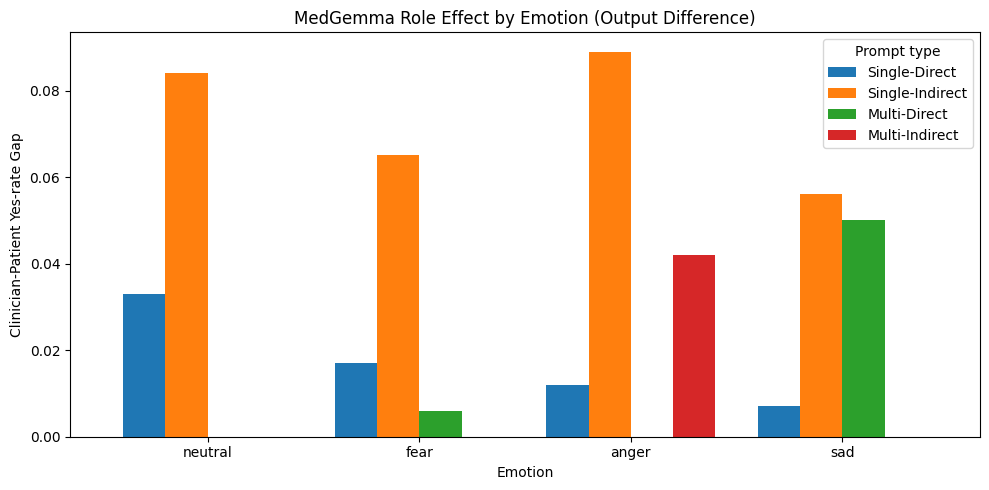

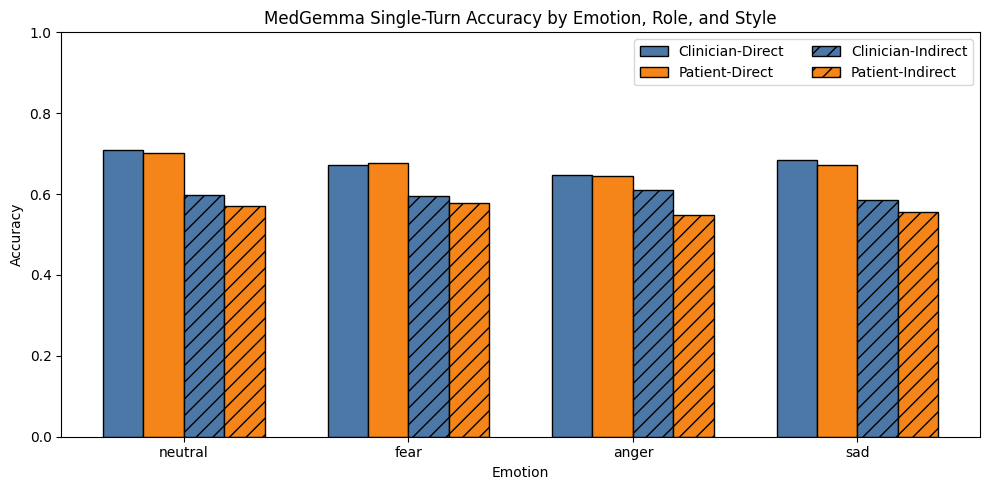

,emotion,single_direct_yes_gap,single_indirect_yes_gap,multi_direct_yes_gap,multi_indirect_yes_gap,single_direct_acc_gap,single_indirect_acc_gap,multi_direct_acc_gap,multi_indirect_acc_gap
0,neutral,0.033,0.084,0.000,0.000,0.008,0.028,0.000,0.000
1,fear,0.017,0.065,0.006,0.000,0.004,0.018,0.052,0.000
2,anger,0.012,0.089,0.000,0.042,0.004,0.061,0.000,0.105
3,sad,0.007,0.056,0.050,0.000,0.013,0.030,0.134,0.000


In [8]:
emotions = ["neutral", "fear", "anger", "sad"]
role_effect_rows = []

def get_yes_rate(df, prompt, mode):
    col = "single_yes_rate" if mode == "single" else "multi_yes_rate"
    rows = df.loc[df["prompt"] == prompt, col]
    return rows.iloc[0] if not rows.empty else np.nan

def get_acc(df, prompt, mode):
    col = "single_Acc" if mode == "single" else "multi_Acc"
    rows = df.loc[df["prompt"] == prompt, col]
    return rows.iloc[0] if not rows.empty else np.nan

for emo in emotions:
    d_clin = f"clin_{emo}_dir"
    d_pat = f"pat_{emo}_dir"
    i_clin = f"clin_{emo}_Indir"
    i_pat = f"pat_{emo}_Indir"

    role_effect_rows.append({
        "emotion": emo,
        "single_direct_yes_gap": abs(get_yes_rate(yes_bias_table, d_clin, "single") - get_yes_rate(yes_bias_table, d_pat, "single")),
        "single_indirect_yes_gap": abs(get_yes_rate(yes_bias_table, i_clin, "single") - get_yes_rate(yes_bias_table, i_pat, "single")),
        "multi_direct_yes_gap": abs(get_yes_rate(yes_bias_table, d_clin, "multi") - get_yes_rate(yes_bias_table, d_pat, "multi")),
        "multi_indirect_yes_gap": abs(get_yes_rate(yes_bias_table, i_clin, "multi") - get_yes_rate(yes_bias_table, i_pat, "multi")),
        "single_direct_acc_gap": abs(get_acc(wide_table, d_clin, "single") - get_acc(wide_table, d_pat, "single")),
        "single_indirect_acc_gap": abs(get_acc(wide_table, i_clin, "single") - get_acc(wide_table, i_pat, "single")),
        "multi_direct_acc_gap": abs(get_acc(wide_table, d_clin, "multi") - get_acc(wide_table, d_pat, "multi")),
        "multi_indirect_acc_gap": abs(get_acc(wide_table, i_clin, "multi") - get_acc(wide_table, i_pat, "multi")),
    })

role_effect_table = pd.DataFrame(role_effect_rows).round(3)

role_yes_plot_df = role_effect_table.set_index("emotion")[[
    "single_direct_yes_gap",
    "single_indirect_yes_gap",
    "multi_direct_yes_gap",
    "multi_indirect_yes_gap",
]].rename(columns={
    "single_direct_yes_gap": "Single-Direct",
    "single_indirect_yes_gap": "Single-Indirect",
    "multi_direct_yes_gap": "Multi-Direct",
    "multi_indirect_yes_gap": "Multi-Indirect",
})

ax = role_yes_plot_df.plot(kind="bar", figsize=(10, 5), width=0.8)
ax.set_xlabel("Emotion")
ax.set_ylabel("Clinician-Patient Yes-rate Gap")
ax.set_title(f"{MODEL_TITLE} Role Effect by Emotion (Output Difference)")
ax.set_xticklabels(role_yes_plot_df.index, rotation=0)
ax.legend(title="Prompt type")
plt.tight_layout()
plt.show()

single_role_plot = []
for emo in emotions:
    single_role_plot.append({
        "emotion": emo,
        "clin_direct": get_acc(wide_table, f"clin_{emo}_dir", "single"),
        "pat_direct": get_acc(wide_table, f"pat_{emo}_dir", "single"),
        "clin_indirect": get_acc(wide_table, f"clin_{emo}_Indir", "single"),
        "pat_indirect": get_acc(wide_table, f"pat_{emo}_Indir", "single"),
    })

single_role_df = pd.DataFrame(single_role_plot).set_index("emotion")
x = np.arange(len(single_role_df.index))
width = 0.18
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - 1.5 * width, single_role_df["clin_direct"], width=width, label="Clinician-Direct", color="#4C78A8", edgecolor="black")
ax.bar(x - 0.5 * width, single_role_df["pat_direct"], width=width, label="Patient-Direct", color="#F58518", edgecolor="black")
ax.bar(x + 0.5 * width, single_role_df["clin_indirect"], width=width, label="Clinician-Indirect", color="#4C78A8", edgecolor="black", hatch="//")
ax.bar(x + 1.5 * width, single_role_df["pat_indirect"], width=width, label="Patient-Indirect", color="#F58518", edgecolor="black", hatch="//")
ax.set_xticks(x)
ax.set_xticklabels(single_role_df.index, rotation=0)
ax.set_xlabel("Emotion")
ax.set_ylabel("Accuracy")
ax.set_title(f"{MODEL_TITLE} Single-Turn Accuracy by Emotion, Role, and Style")
ax.set_ylim(0, 1.0)
ax.legend(ncol=2)
plt.tight_layout()
plt.show()

role_effect_table

## Direct vs indirect comparison

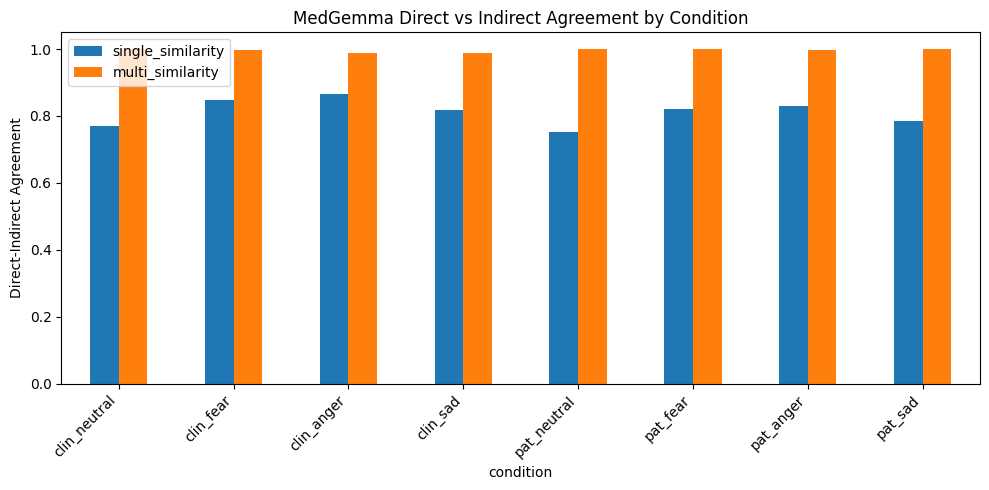

,condition,single_similarity,multi_similarity,single_acc_direct,single_acc_indirect,single_acc_change_indirect_minus_direct,multi_acc_direct,multi_acc_indirect,multi_acc_change_indirect_minus_direct,single_yes_rate_direct,single_yes_rate_indirect,multi_yes_rate_direct,multi_yes_rate_indirect
0,clin_neutral,0.771,1.000,0.709,0.598,-0.111,0.333,0.333,0.000,0.324,0.153,0.083,0.083
1,clin_fear,0.849,0.996,0.672,0.595,-0.077,0.385,0.333,-0.052,0.251,0.134,0.077,0.083
2,clin_anger,0.865,0.988,0.648,0.609,-0.039,0.385,0.438,0.053,0.202,0.121,0.077,0.125
3,clin_sad,0.816,0.988,0.684,0.586,-0.098,0.467,0.333,-0.134,0.255,0.104,0.133,0.083
4,pat_neutral,0.751,1.000,0.701,0.570,-0.131,0.333,0.333,0.000,0.291,0.068,0.083,0.083
5,pat_fear,0.820,1.000,0.676,0.577,-0.099,0.333,0.333,0.000,0.234,0.069,0.083,0.083
6,pat_anger,0.829,0.996,0.644,0.548,-0.096,0.385,0.333,-0.052,0.190,0.032,0.077,0.083
7,pat_sad,0.784,1.000,0.671,0.556,-0.115,0.333,0.333,0.000,0.248,0.048,0.083,0.083


In [9]:
direct_indirect_rows = []
for role_prefix in ["clin", "pat"]:
    for emo in emotions:
        direct_prompt = f"{role_prefix}_{emo}_dir"
        indirect_prompt = f"{role_prefix}_{emo}_Indir"

        direct_indirect_rows.append({
            "condition": f"{role_prefix}_{emo}",
            "single_similarity": safe_similarity(single_sim_matrix_nc, direct_prompt, indirect_prompt),
            "multi_similarity": safe_similarity(multi_sim_matrix_nc, direct_prompt, indirect_prompt),
            "single_acc_direct": get_metric(wide_table, direct_prompt, "single_Acc"),
            "single_acc_indirect": get_metric(wide_table, indirect_prompt, "single_Acc"),
            "single_acc_change_indirect_minus_direct": get_metric(wide_table, indirect_prompt, "single_Acc") - get_metric(wide_table, direct_prompt, "single_Acc"),
            "multi_acc_direct": get_metric(wide_table, direct_prompt, "multi_Acc"),
            "multi_acc_indirect": get_metric(wide_table, indirect_prompt, "multi_Acc"),
            "multi_acc_change_indirect_minus_direct": get_metric(wide_table, indirect_prompt, "multi_Acc") - get_metric(wide_table, direct_prompt, "multi_Acc"),
            "single_yes_rate_direct": yes_rate(get_metric(wide_table, direct_prompt, "single_Yes"), get_metric(wide_table, direct_prompt, "single_No")),
            "single_yes_rate_indirect": yes_rate(get_metric(wide_table, indirect_prompt, "single_Yes"), get_metric(wide_table, indirect_prompt, "single_No")),
            "multi_yes_rate_direct": yes_rate(get_metric(wide_table, direct_prompt, "multi_Yes"), get_metric(wide_table, direct_prompt, "multi_No")),
            "multi_yes_rate_indirect": yes_rate(get_metric(wide_table, indirect_prompt, "multi_Yes"), get_metric(wide_table, indirect_prompt, "multi_No")),
        })

direct_indirect_compare_table = pd.DataFrame(direct_indirect_rows)

style_plot_df = direct_indirect_compare_table.set_index("condition")[["single_similarity", "multi_similarity"]]
ax = style_plot_df.plot(kind="bar", figsize=(10, 5))
ax.set_ylabel("Direct-Indirect Agreement")
ax.set_title(f"{MODEL_TITLE} Direct vs Indirect Agreement by Condition")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

direct_indirect_compare_table.round(3)